In [13]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

RANDOM_SEED = 42

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

train["time_stamp"] = pd.to_datetime(train["time_stamp"])
test["time_stamp"] = pd.to_datetime(test["time_stamp"])

# Bin used throughout for every time-based join (lag features AND, in v2, domain features)
train["time_bin"] = train["time_stamp"].dt.floor("6h")
test["time_bin"] = test["time_stamp"].dt.floor("6h")

train["click"] = pd.to_numeric(train["click"])
test["click"] = pd.to_numeric(test["click"])

print("train:", train.shape, "test:", test.shape)
print(f"train CTR: {train['click'].mean():.4%}  |  test CTR: {test['click'].mean():.4%}")

train: (240000, 22) test: (60000, 22)
train CTR: 20.1858%  |  test CTR: 19.2567%


# Time Series, Time lag and merge

In [15]:
# v2: Notice train and test file are continuous in time => combine 2 files for time-series features
#  - lag features get a real trailing window in the TEST period too (not just train)
#  - domain features can be computed causally (only bins strictly BEFORE each row)
# No row ever uses its own click, and no row ever uses a bin at/after its own bin --
# only actual history that would have already happened by that point in time.
combined = pd.concat([
    train[["adgroup_id", "time_bin", "click", "price"]],
    test[["adgroup_id", "time_bin", "click", "price"]],
], ignore_index=True)
combined["revenue"] = combined["price"] * combined["click"]

FULL_BINS = pd.date_range(combined["time_bin"].min(), combined["time_bin"].max(), freq="6h")
print(f"{len(FULL_BINS)} six-hour bins spanning train+test")

33 six-hour bins spanning train+test


In [16]:
# v2 fix: resample over FULL_BINS (train+test)
ts_full = (
    combined.groupby("time_bin")["click"].sum()
    .reindex(FULL_BINS, fill_value=0)
    .rename("Clicks_T").to_frame()
)

ts_full["prev_6h"] = ts_full["Clicks_T"].shift(1)
ts_full["prev_12h"] = ts_full["Clicks_T"].shift(2)
ts_full["yesterday"] = ts_full["Clicks_T"].shift(4)
ts_full["2_days_ago"] = ts_full["Clicks_T"].shift(8)
ts_full["3_days_ago"] = ts_full["Clicks_T"].shift(12)
ts_full.head()

,Clicks_T,prev_6h,prev_12h,yesterday,2_days_ago,3_days_ago
2017-05-05 12:00:00,277,NaN,NaN,NaN,NaN,NaN
2017-05-05 18:00:00,417,277.0,NaN,NaN,NaN,NaN
2017-05-06 00:00:00,2129,417.0,277.0,NaN,NaN,NaN
2017-05-06 06:00:00,2155,2129.0,417.0,NaN,NaN,NaN
2017-05-06 12:00:00,2115,2155.0,2129.0,277.0,NaN,NaN


In [17]:
lag_cols = ["prev_6h", "prev_12h", "yesterday", "2_days_ago", "3_days_ago"]

train = train.merge(
    ts_full[lag_cols], left_on="time_bin", right_index=True, how="left"
).fillna(0)
test = test.merge(
    ts_full[lag_cols], left_on="time_bin", right_index=True, how="left"
).fillna(0)

# sanity check for the v1 bug: this used to be 94.9%
zero_share = (test[lag_cols] == 0).all(axis=1).mean()
print(f"Share of TEST rows with all-zero lag features: {zero_share:.1%}")

Share of TEST rows with all-zero lag features: 0.0%  (was 94.9% before the v2 fix)


In [18]:
train.tail(5)

,userid,time_stamp,adgroup_id,pid,cate_id,campaign_id,customer,brand,price,cms_segid,...,click,date,hour,weekday,time_bin,prev_6h,prev_12h,yesterday,2_days_ago,3_days_ago
239995,526028,2017-05-12 04:24:07,649815,430539_1007,1665,223117,207959,0.0,286.0,33,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239996,34897,2017-05-12 04:24:07,739213,430548_1007,4520,4406,81699,0.0,188.0,0,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239997,1110128,2017-05-12 04:24:08,580700,430548_1007,1665,363316,65469,234846.0,598.0,44,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239998,371323,2017-05-12 04:24:12,836889,430548_1007,6261,118601,28529,82527.0,176.0,0,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0
239999,426168,2017-05-12 04:24:15,836889,430548_1007,6261,118601,28529,82527.0,176.0,0,...,0,2017-05-12,4,4,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0


# Domain (Total Click, Total Impression, CTR, Total Revenue)

In [7]:
# v2: build a per-(adgroup_id, time_bin) EXPANDING, PRIOR-BINS-ONLY aggregate.
# A row in bin T only ever sees history from bins strictly before T -- exactly what
# would be available in a real-time system, and never its own outcome.
CATALOG_PRODUCTS = pd.concat([train["adgroup_id"], test["adgroup_id"]]).unique()

bin_agg = (
    combined.groupby(["adgroup_id", "time_bin"])
    .agg(
        impressions=("click", "count"), 
        clicks=("click", "sum"), 
        revenue=("revenue", "sum")
        )
    .reset_index()
)

# reindex to every (product, bin) combo so a quiet bin still carries the running total forward
full_index = pd.MultiIndex.from_product([CATALOG_PRODUCTS, FULL_BINS], names=["adgroup_id", "time_bin"])
bin_agg_full = (
    bin_agg.set_index(["adgroup_id", "time_bin"])
    .reindex(full_index, fill_value=0)
    .reset_index()
    .sort_values(["adgroup_id", "time_bin"])
)

g = bin_agg_full.groupby("adgroup_id")
bin_agg_full["cum_impressions"] = g["impressions"].cumsum()
bin_agg_full["cum_clicks"] = g["clicks"].cumsum()
bin_agg_full["cum_revenue"] = g["revenue"].cumsum()

# shift(1) per product: "everything strictly BEFORE this bin" -- never this bin's own data
g2 = bin_agg_full.groupby("adgroup_id")
bin_agg_full["Total_Impression"] = g2["cum_impressions"].shift(1).fillna(0)
bin_agg_full["Total_Click"] = g2["cum_clicks"].shift(1).fillna(0)
bin_agg_full["Total_Revenue"] = g2["cum_revenue"].shift(1).fillna(0)
bin_agg_full["CTR"] = (bin_agg_full["Total_Click"] / bin_agg_full["Total_Impression"]).fillna(0)

DOMAIN_FEATURES = ["Total_Impression", "Total_Click", "CTR", "Total_Revenue"]
domain_by_bin = bin_agg_full[["adgroup_id", "time_bin"] + DOMAIN_FEATURES]

# Merge the learned, time-aware metrics back into train and test
train = train.merge(domain_by_bin, on=["adgroup_id", "time_bin"], how="left").fillna(0)
test = test.merge(domain_by_bin, on=["adgroup_id", "time_bin"], how="left").fillna(0)

In [34]:
train.tail()

,userid,time_stamp,adgroup_id,pid,cate_id,campaign_id,customer,brand,price,cms_segid,...,time_bin,prev_6h,prev_12h,yesterday,2_days_ago,3_days_ago,Total_Impression,Total_Click,CTR,Total_Revenue
239995,526028,2017-05-12 04:24:07,649815,430539_1007,1665,223117,207959,0.0,286.0,33,...,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0,423.0,72.0,0.170213,20592.0
239996,34897,2017-05-12 04:24:07,739213,430548_1007,4520,4406,81699,0.0,188.0,0,...,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0,891.0,267.0,0.299663,50196.0
239997,1110128,2017-05-12 04:24:08,580700,430548_1007,1665,363316,65469,234846.0,598.0,44,...,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0,410.0,59.0,0.143902,35282.0
239998,371323,2017-05-12 04:24:12,836889,430548_1007,6261,118601,28529,82527.0,176.0,0,...,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0,1060.0,279.0,0.263208,49104.0
239999,426168,2017-05-12 04:24:15,836889,430548_1007,6261,118601,28529,82527.0,176.0,0,...,2017-05-12,507.0,2495.0,2390.0,2577.0,2516.0,1060.0,279.0,0.263208,49104.0


# Model Fitting

In [9]:
NUMERIC_FEATURES = ["price"] + lag_cols + DOMAIN_FEATURES
CATEGORICAL_FEATURES = [
    "adgroup_id",
    "cate_id",
    "cms_group_id",
    "final_gender_code",
    "age_level",
    "pvalue_level",
    "shopping_level",
    "occupation",
    "new_user_class_level",
    "pid",
    "hour",
    "weekday"
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "click"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

model = Pipeline(
        [("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['price','prev_6h','prev_12h',...,'pid','hour','weekday']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

In [22]:
y_score = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)
ll = log_loss(y_test, y_score)
print(f"AUC:      {auc:.4f}  (0.5 = random)")
print(f"Log loss: {ll:.4f}  (lower is better)")

AUC:      0.5714  (0.5 = random)
Log loss: 0.4851  (lower is better)


In [23]:
# quick look at what the model actually leans on now that leakage is gone
clf = model.named_steps["clf"]
coefs = clf.coef_[0][:len(NUMERIC_FEATURES)]
pd.Series(coefs, index=NUMERIC_FEATURES).sort_values(key=abs, ascending=False).to_frame("coefficient")

,coefficient
Total_Click,-0.167898
Total_Impression,0.092967
Total_Revenue,-0.064257
2_days_ago,-0.042121
3_days_ago,0.018617
prev_6h,0.018190
CTR,-0.015880
price,0.009566
prev_12h,-0.008308
yesterday,0.002260


In [24]:
PRODUCT_FEATURES = ["adgroup_id", "cate_id", "price"]
USER_FEATURES = [
    "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "pid", "hour", "weekday",
]
K_VALUES = [10, 50, 100]

catalog = (
    pd.concat([train[PRODUCT_FEATURES], test[PRODUCT_FEATURES]])
    .drop_duplicates("adgroup_id")
    .reset_index(drop=True)
)
n_catalog = len(catalog)
print(f"Product catalog: {n_catalog} unique products")

Product catalog: 300 unique products


In [25]:
# One query per real click in the test period. A user who clicked twice
# becomes two separate queries here (simpler code than tracking per-user sets).
queries = test[test["click"] == 1].reset_index(drop=True)
queries["query_id"] = np.arange(len(queries))
n_queries = len(queries)
print(f"Evaluating {n_queries} clicks")

Evaluating 11554 clicks


In [26]:
# Cross join: every click paired with every catalog product, so we can score
# "if this user showed up right now, how would each of the 300 products rank?"
# - lag_cols travel with the QUERY (time-bin-level: same for every candidate product
#   in a given query, since it's a market-wide signal)
# - DOMAIN_FEATURES are joined per (candidate product, query's time_bin) -- each
#   candidate gets ITS OWN causal history as of that exact moment, not the true
#   clicked product's history applied to everyone
cross = (
    queries[["query_id", "adgroup_id", "time_bin"] + USER_FEATURES + lag_cols]
    .rename(columns={"adgroup_id": "true_adgroup_id"})
    .merge(catalog, how="cross")
)
cross = cross.merge(domain_by_bin, on=["adgroup_id", "time_bin"], how="left").fillna(0)

cross["score"] = model.predict_proba(cross[FEATURES])[:, 1]
cross["rank"] = cross.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1
cross

,query_id,true_adgroup_id,time_bin,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level,...,3_days_ago,adgroup_id,cate_id,price,Total_Impression,Total_Click,CTR,Total_Revenue,score,rank
0,0,716643,2017-05-12 00:00:00,1,2,1,2.0,3,0,0.0,...,2516.0,591197,4282,439.00,654.0,144.0,0.220183,63216.0,0.200384,96
1,0,716643,2017-05-12 00:00:00,1,2,1,2.0,3,0,0.0,...,2516.0,632232,4281,98.00,795.0,117.0,0.147170,11466.0,0.144363,265
2,0,716643,2017-05-12 00:00:00,1,2,1,2.0,3,0,0.0,...,2516.0,664671,6261,136.25,1265.0,286.0,0.226087,38967.5,0.210738,72
3,0,716643,2017-05-12 00:00:00,1,2,1,2.0,3,0,0.0,...,2516.0,578422,6261,328.00,1168.0,189.0,0.161815,61992.0,0.154338,236
4,0,716643,2017-05-12 00:00:00,1,2,1,2.0,3,0,0.0,...,2516.0,725105,4284,118.00,2600.0,792.0,0.304615,93456.0,0.268804,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3466195,11553,736349,2017-05-13 12:00:00,2,2,2,1.0,3,0,0.0,...,2626.0,754288,4281,138.00,797.0,144.0,0.180678,19872.0,0.166551,146
3466196,11553,736349,2017-05-13 12:00:00,2,2,2,1.0,3,0,0.0,...,2626.0,801532,6261,163.00,818.0,107.0,0.130807,17441.0,0.111788,288
3466197,11553,736349,2017-05-13 12:00:00,2,2,2,1.0,3,0,0.0,...,2626.0,776726,6261,124.00,584.0,105.0,0.179795,13020.0,0.181426,93
3466198,11553,736349,2017-05-13 12:00:00,2,2,2,1.0,3,0,0.0,...,2626.0,778486,6261,158.00,650.0,99.0,0.152308,15642.0,0.156335,179


In [27]:
# Where did the actually-clicked product land in the ranking?
true_product_rank = (
    cross.loc[cross["adgroup_id"] == cross["true_adgroup_id"], ["query_id", "rank"]]
    .set_index("query_id")["rank"]
)
true_product_rank

query_id
0        160
1        190
2        222
3        181
4        293
        ... 
11549    105
11550    127
11551    284
11552    281
11553    252
Name: rank, Length: 11554, dtype: int64

In [28]:
rows = []
for k in K_VALUES:
    hit = true_product_rank < k

    recall_at_k = hit.mean()                    # exactly 1 relevant product per query
    precision_at_k = hit.sum() / (n_queries * k)  # pool every query's K slots together

    random_precision = 1 / n_catalog
    random_recall = k / n_catalog

    rows.append({
        "K": k,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k,
        "Random Precision@K": random_precision,
        "Random Recall@K": random_recall,
        "Precision lift": precision_at_k / random_precision,
    })

user_results = pd.DataFrame(rows).set_index("K")
user_results

,Precision@K,Recall@K,Random Precision@K,Random Recall@K,Precision lift
K,,,,,
10,0.005764,0.057642,0.003333,0.033333,1.729271
50,0.005257,0.262853,0.003333,0.166667,1.577116
100,0.004682,0.468236,0.003333,0.333333,1.404708


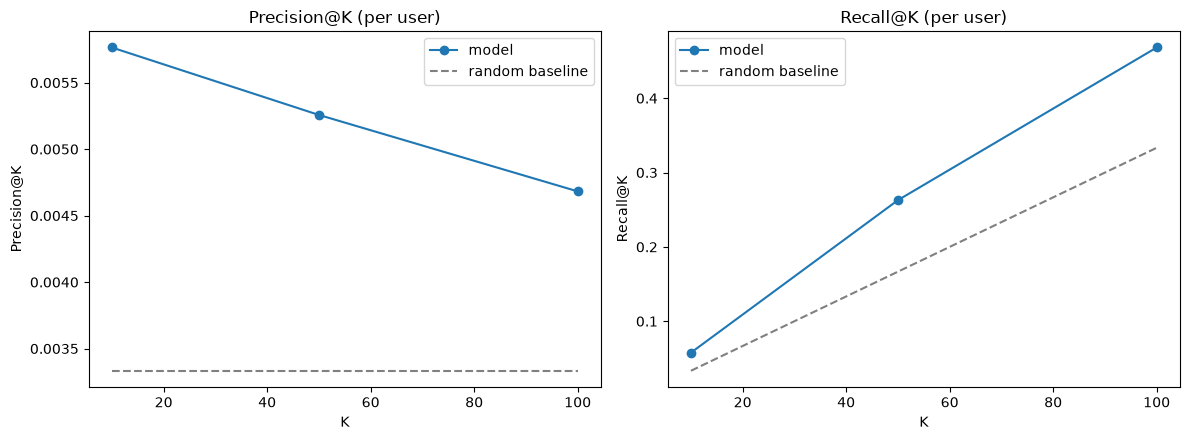

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(user_results.index, user_results["Precision@K"], marker="o", label="model")
axes[0].plot(user_results.index, user_results["Random Precision@K"], color="gray", linestyle="--", label="random baseline")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K (per user)")
axes[0].legend()

axes[1].plot(user_results.index, user_results["Recall@K"], marker="o", label="model")
axes[1].plot(user_results.index, user_results["Random Recall@K"], color="gray", linestyle="--", label="random baseline")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K (per user)")
axes[1].legend()

plt.tight_layout()
plt.show()


## v2 — what changed vs. v1


1. **Lag features are  built over `train + test` combined**, not `train` alone —
   so every test-period bin gets a real trailing window instead of falling outside
   `ts_train`'s range and silently zero-filling (was 94.9% of test rows, now 0%).
2. **Domain features (`Total_Impression/Total_Click/CTR/Total_Revenue`) are now an
   expanding, prior-bins-only aggregate per `(adgroup_id, time_bin)`**, instead of a
   single train-wide total merged onto every row of that product (which let each
   row's own click leak into its own feature). A row now only ever sees history from
   strictly earlier time bins — for itself and, in the Top-K eval, for every
   candidate product it's compared against.

Both are "look-back only" by construction: later bins can use actual outcomes from
earlier bins (a real system would too, as time passes), but no row ever sees its own
outcome or anything from its own bin or later.

## Results

In [33]:
import pandas as pd

comparison = pd.DataFrame({
    "Baseline":            [0.5759, 0.4856, 0.0106, 0.1065, 3.19],
    "FE":           [0.5714, 0.4851, 0.0058, 0.0576, 1.73],
}, index=["AUC", "Log loss", "Precision@10", "Recall@10", "Precision@10 lift vs random"])
comparison

,Baseline,FE
AUC,0.5759,0.5714
Log loss,0.4856,0.4851
Precision@10,0.0106,0.0058
Recall@10,0.1065,0.0576
Precision@10 lift vs random,3.1900,1.7300


**The v2 numbers are worse than the baseline**. `CTR`, `Total_Impression`, `Total_Click`, and
`Total_Revenue` carry very little real signal for this dataset, and Precision@10
lift drops from 3.19x to 1.73x.

Two things explain why the *causal* version underperforms even the plain baseline,
rather than just landing at "no better, no worse":

- **Sparsity from the expanding window.** With ~300 products and only ~7 days of
  combined history, many `(product, time_bin)` cells early in the timeline have
  little or no prior data — `Total_Impression = 0` and `CTR = 0` for a real chunk of
  rows, which is a very different signal from "this product has a low CTR". The
  model can't currently tell "no data yet" apart from "bad product", which adds
  noise it has to fight through.
- **Time confound.** Cumulative counts only ever go up, so `Total_Impression` is
  partly just a proxy for "how late in the week is it" rather than "how good is this
  product" — which can pull the model in the wrong direction once it's no longer
  propped up by leakage.

**Takeaway:** the recency/domain feature ideas aren't validated by this experiment —
run cleanly, they underperform the simple baseline. That's a legitimate, useful
result (it tells you *not* to ship these features as-is), but it also points at
concrete next steps if you want to keep pursuing them:
- Smooth `CTR` with a prior (e.g. Bayesian/Laplace smoothing, or a minimum-impression
  threshold before trusting it) so "no data yet" doesn't look identical to "0% CTR".
- Get more historical depth before evaluating lag/domain features — a week is thin
  for day-level seasonality or a stable per-product CTR estimate.
- Try a model that can weight/interact features non-linearly (e.g. gradient-boosted
  trees), which can learn to downweight sparse/early-window features more gracefully
  than a linear model can.